# Task 08 - Classification Models
### Logistic Regression, Decision Trees & Random Forests

**PKCERT AI & Software Development Internship**
Author: Abdullah Amir

This notebook builds and evaluates three classifiers on the **Pima Indians Diabetes** dataset: 768 patients described by 8 clinical measurements, each labelled diabetic or not. The goal is to predict whether a patient has diabetes (`Outcome = 1`) from measurements like glucose, BMI, and age. We cover Logistic Regression (Part A), the full set of classification metrics (Part B), Decision Trees and Random Forests (Part C), and a head-to-head comparison with a recommendation (Part D).

In [1]:
# Environment
import sys, sklearn, pandas as pd, numpy as np, matplotlib
print("Python      :", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("matplotlib  :", matplotlib.__version__)

Python      : 3.13.1
scikit-learn: 1.7.2
pandas      : 2.3.3
numpy       : 2.3.1
matplotlib  : 3.10.3


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve, roc_auc_score)

np.random.seed(42)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

## Loading and cleaning the data

The eight features are `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction` and `Age`; the target is `Outcome` (1 = diabetes). About 35% of the patients are diabetic, so the classes are imbalanced, which is exactly why we cannot rely on accuracy alone later.

A quirk of this dataset is that several columns use **0 to mean "not recorded"**. A glucose or BMI of zero is physiologically impossible, so those zeros are really missing values. We replace them with the column median, a simple and robust imputation.

In [3]:
df = pd.read_csv("diabetes.csv")
print("Shape:", df.shape)
print(df["Outcome"].value_counts().rename({0: "no diabetes", 1: "diabetes"}))
print("Diabetic fraction:", round(df["Outcome"].mean(), 4))
df.head()

Shape: (768, 9)
Outcome
no diabetes    500
diabetes       268
Name: count, dtype: int64
Diabetic fraction: 0.349


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Zeros in these columns are impossible -> treat as missing, impute with the median.
zero_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("Zeros (missing) before cleaning:")
print((df[zero_missing] == 0).sum())

for c in zero_missing:
    df[c] = df[c].replace(0, np.nan)
    df[c] = df[c].fillna(df[c].median())

print("\nZeros after imputation:", int((df[zero_missing] == 0).sum().sum()))

Zeros (missing) before cleaning:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Zeros after imputation: 0


## Part A - Logistic Regression

**Working principle.** Logistic Regression is a linear model for classification. It takes a weighted sum of the features, `z = w.x + b`, just like linear regression, then squashes that number through the **sigmoid** function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

which maps any real value into the range 0 to 1 and is read as the probability of the positive class. If the probability is above 0.5 we predict diabetes, otherwise no diabetes. The weights are learned by maximising the likelihood of the observed labels (equivalently, minimising log-loss) with an iterative solver. Because the model is linear in the features, the sign and size of each weight tell you how each measurement pushes the risk up or down, which makes it easy to interpret.

**Real-world application.** It is the standard tool for medical risk scoring and credit decisions: estimating a patient's probability of a disease, whether a transaction is fraudulent, or whether a customer will churn, all cases where you want a calibrated probability and a model you can actually explain.

**Preparation.** We split 80/20 with stratification (both sets keep the 35% diabetic ratio) and standardise the features. Standardising matters because the columns live on very different scales (insulin in the hundreds, pedigree around 0.5), and the solver converges faster and fairer when they share a common scale.

In [5]:
X = df.drop(columns="Outcome")
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
print("Train:", X_train.shape[0], " Test:", X_test.shape[0])

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=5000, random_state=42)
logreg.fit(X_train_s, y_train)
y_pred_lr = logreg.predict(X_test_s)
y_prob_lr = logreg.predict_proba(X_test_s)[:, 1]
print("Logistic Regression trained.")

Train: 614  Test: 154
Logistic Regression trained.


## Part B - Classification Metrics

Accuracy alone is misleading with imbalanced classes (a model that always guessed "no diabetes" would already score 65% here), so we look at the full set. All four metrics are built from the four cells of the confusion matrix: true negatives (TN), false positives (FP), false negatives (FN), and true positives (TP).

- **Accuracy** = (TP + TN) / all. The overall share of correct predictions. A good headline, but blind to *which* class is being missed.
- **Precision** = TP / (TP + FP). Of the patients we flagged as diabetic, how many really were. High precision means few false alarms.
- **Recall** (sensitivity) = TP / (TP + FN). Of the patients who really had diabetes, how many we caught. **This is the metric that matters most in medical screening**, because a false negative (telling a sick patient they are healthy) is the costliest error.
- **F1-score** = the harmonic mean of precision and recall, `2PR/(P+R)`. One number that stays low unless *both* are high, so it is the honest summary when you care about both.

In [6]:
def evaluate(name, y_true, y_pred):
    print(f"=== {name} ===")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.4f}")
    return dict(Accuracy=accuracy_score(y_true, y_pred),
                Precision=precision_score(y_true, y_pred),
                Recall=recall_score(y_true, y_pred),
                F1=f1_score(y_true, y_pred))

m_lr = evaluate("Logistic Regression", y_test, y_pred_lr)
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_lr), 4))
print()
print(classification_report(y_test, y_pred_lr, target_names=["no diabetes", "diabetes"]))

=== Logistic Regression ===
Accuracy : 0.7078
Precision: 0.6000
Recall   : 0.5000
F1-score : 0.5455
ROC-AUC  : 0.813

              precision    recall  f1-score   support

 no diabetes       0.75      0.82      0.78       100
    diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



### Confusion matrix

Rows are the true class, columns are the predicted class. The diagonal is correct predictions; the off-diagonal cells are the two kinds of mistake. The bottom-left cell (false negatives, missed diabetics) is the one we care about most in a screening setting.

[[82 18]
 [27 27]]


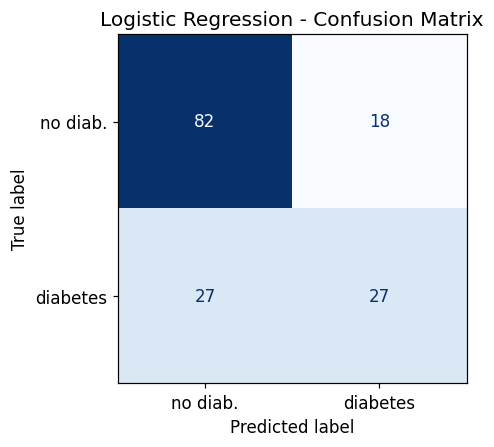

In [7]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ConfusionMatrixDisplay(cm, display_labels=["no diab.", "diabetes"]).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Logistic Regression - Confusion Matrix")
plt.tight_layout(); plt.show()

## Part C - Decision Trees & Random Forests

**Decision Tree.** A tree asks a sequence of yes/no questions on the features ("is glucose > 128?") and follows the branches down to a leaf holding the predicted class. At each split it picks the feature and threshold that best separate the classes, measured by **Gini impurity** or entropy. Trees need no feature scaling, capture non-linear boundaries, and are easy to read, but a fully grown tree memorises the training data and overfits. We cap the depth at 4 to keep it honest and legible.

**Random Forest.** A forest is an **ensemble** of many decision trees. Each tree is trained on a bootstrap sample of the rows and, at every split, may only consider a random subset of the features. The trees therefore make different errors, and averaging their votes cancels much of the noise. This *bagging* keeps most of a tree's flexibility while sharply cutting the variance that makes a single tree fragile.

In [8]:
# Decision Tree - no scaling needed
dtree = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree.fit(X_train, y_train)
y_pred_dt = dtree.predict(X_test)
y_prob_dt = dtree.predict_proba(X_test)[:, 1]
m_dt = evaluate("Decision Tree (max_depth=4)", y_test, y_pred_dt)
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_dt), 4))

=== Decision Tree (max_depth=4) ===
Accuracy : 0.7857
Precision: 0.6981
Recall   : 0.6852
F1-score : 0.6916
ROC-AUC  : 0.7887


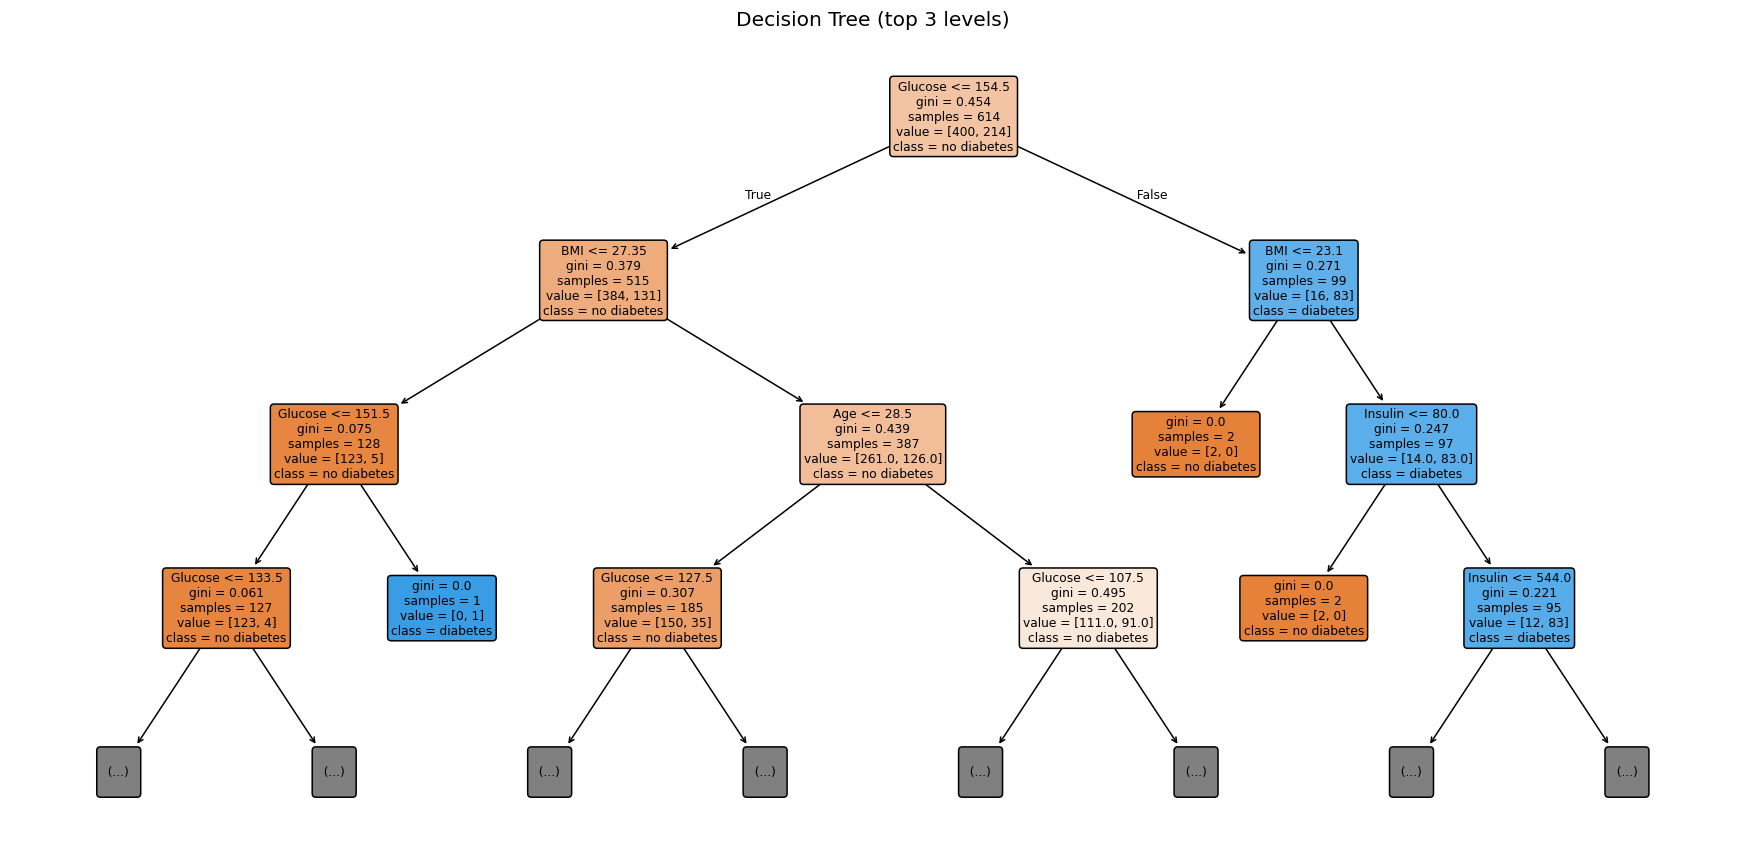

In [9]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(dtree, feature_names=X.columns, class_names=["no diabetes", "diabetes"],
          filled=True, rounded=True, fontsize=8, max_depth=3, ax=ax)
ax.set_title("Decision Tree (top 3 levels)")
plt.tight_layout(); plt.show()

In [10]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
m_rf = evaluate("Random Forest (200 trees)", y_test, y_pred_rf)
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

=== Random Forest (200 trees) ===
Accuracy : 0.7403
Precision: 0.6522
Recall   : 0.5556
F1-score : 0.6000
ROC-AUC  : 0.8161


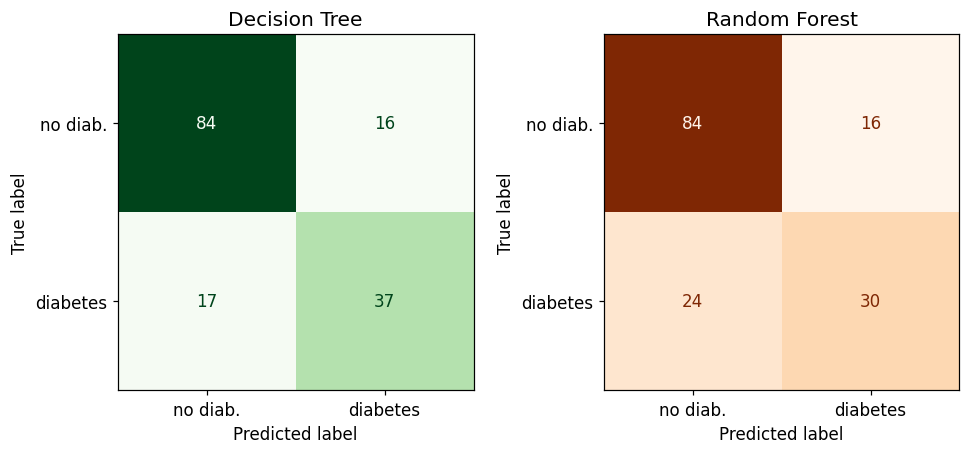

In [11]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt),
                       display_labels=["no diab.", "diabetes"]).plot(
    ax=axes[0], cmap="Greens", colorbar=False, values_format="d")
axes[0].set_title("Decision Tree")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=["no diab.", "diabetes"]).plot(
    ax=axes[1], cmap="Oranges", colorbar=False, values_format="d")
axes[1].set_title("Random Forest")
plt.tight_layout(); plt.show()

### Which features drive the forest?

A Random Forest reports how much each feature contributed to reducing impurity across all its trees. `Glucose` dominates, followed by `BMI`, `DiabetesPedigreeFunction` (family history) and `Age`, which is exactly the clinical picture you would expect for type 2 diabetes.

Glucose                     0.268355
BMI                         0.158066
DiabetesPedigreeFunction    0.124386
Age                         0.120345
Insulin                     0.092340
BloodPressure               0.083938
Pregnancies                 0.079370
SkinThickness               0.073200
dtype: float64


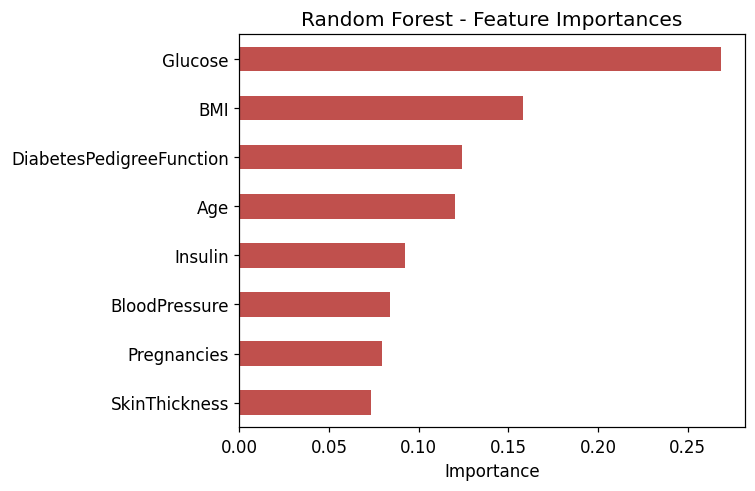

In [12]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
fig, ax = plt.subplots(figsize=(7, 4.6))
importances.iloc[::-1].plot.barh(ax=ax, color="#c0504d")
ax.set_title("Random Forest - Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()

**Advantages and limitations.**

| | Decision Tree | Random Forest |
|---|---|---|
| Interpretability | Very high, you can read the whole tree | Lower, it is 200 trees averaged |
| Accuracy | Good, but prone to overfitting | Usually higher and steadier |
| Variance | High, sensitive to the training rows | Low, averaging smooths it out |
| Speed | Fast to train and predict | Slower, trains many trees |
| Scaling needed | No | No |

A single tree is the right tool when you must *explain* the decision path; the forest is the right tool when you want the *most stable* accuracy and can treat the model as a black box. We confirm the tree's instability with cross-validation below.

## Part D - Comparative Analysis

We line up all three models on the same held-out test set, then add 5-fold cross-validation and ROC-AUC for a more robust read that does not depend on one lucky split.

In [13]:
metrics_df = pd.DataFrame({"Logistic Regression": m_lr,
                           "Decision Tree": m_dt,
                           "Random Forest": m_rf}).T
metrics_df["ROC-AUC"] = [roc_auc_score(y_test, y_prob_lr),
                         roc_auc_score(y_test, y_prob_dt),
                         roc_auc_score(y_test, y_prob_rf)]
metrics_df.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130
Decision Tree,0.7857,0.6981,0.6852,0.6916,0.7887
Random Forest,0.7403,0.6522,0.5556,0.6000,0.8161


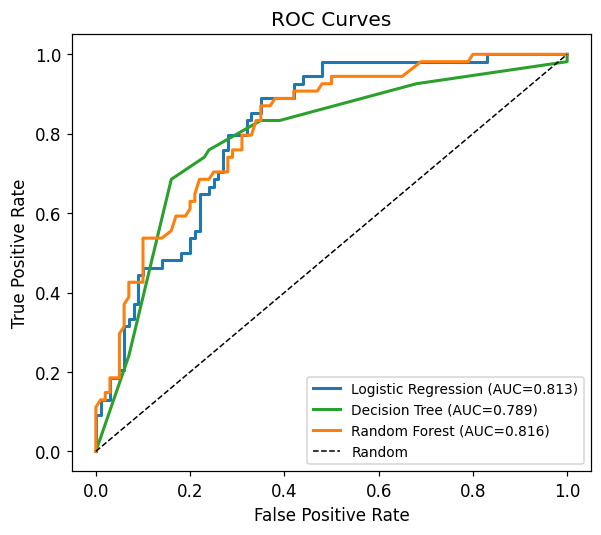

In [14]:
# ROC curves
fig, ax = plt.subplots(figsize=(5.6, 5))
for name, prob, color in [("Logistic Regression", y_prob_lr, "#1f77b4"),
                          ("Decision Tree", y_prob_dt, "#2ca02c"),
                          ("Random Forest", y_prob_rf, "#ff7f0e")]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves"); ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

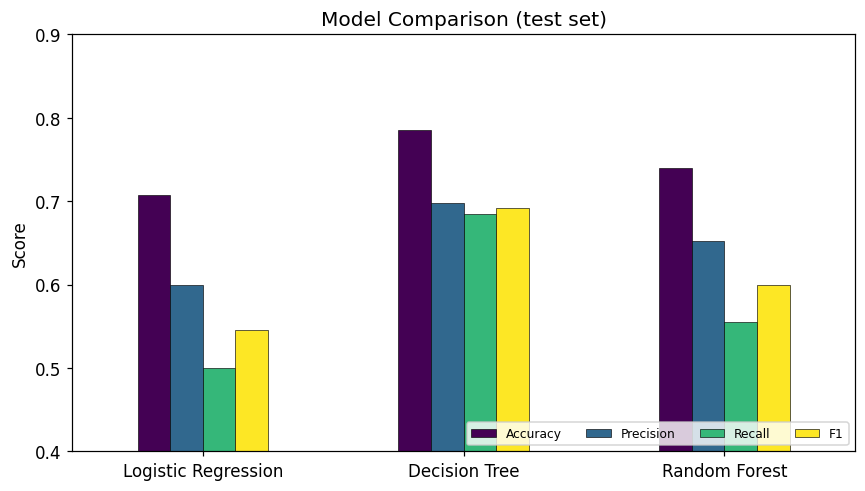

In [15]:
# Metric comparison bar chart
fig, ax = plt.subplots(figsize=(8, 4.6))
metrics_df[["Accuracy", "Precision", "Recall", "F1"]].plot.bar(
    ax=ax, rot=0, colormap="viridis", edgecolor="black", linewidth=0.4)
ax.set_ylim(0.4, 0.9); ax.set_ylabel("Score")
ax.set_title("Model Comparison (test set)")
ax.legend(loc="lower right", ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

In [16]:
# 5-fold cross-validation for a robustness check
X_scaled_full = StandardScaler().fit_transform(X)
print("5-fold CV accuracy:")
for name, model, Xin in [
        ("Logistic Regression", LogisticRegression(max_iter=5000, random_state=42), X_scaled_full),
        ("Decision Tree",       DecisionTreeClassifier(max_depth=4, random_state=42), X),
        ("Random Forest",       RandomForestClassifier(n_estimators=200, random_state=42), X)]:
    s = cross_val_score(model, Xin, y, cv=5, scoring="accuracy")
    print(f"{name:20s}: {s.mean():.4f} (std {s.std():.4f})")

5-fold CV accuracy:
Logistic Regression : 0.7722 (std 0.0180)
Decision Tree       : 0.7318 (std 0.0398)


Random Forest       : 0.7605 (std 0.0354)


### Recommendation

The three models tell a subtle story, and it is a good lesson in not trusting a single split.

- On this **one test split** the Decision Tree looks best (accuracy 0.786, F1 0.692). But **cross-validation exposes it as the least reliable**: its CV accuracy is the lowest (0.732) and its spread is the widest (std 0.040, roughly double the others). That strong test score is largely luck of the split.
- **Logistic Regression** has the best and steadiest cross-validation accuracy (0.772, std 0.018) and a near-top ROC-AUC (0.813). Its weak spot is recall at the default 0.5 threshold (0.500), so out of the box it misses half the diabetics.
- **Random Forest** posts the best ROC-AUC (0.816), the second-best CV accuracy (0.761), and far more stability than the single tree, since averaging 200 trees smooths out the variance.

**For this dataset I recommend the Random Forest.** ROC-AUC measures how well a model *ranks* patients by risk independently of the cut-off, and the forest ranks best, which is what counts in a screening setting where you would lower the decision threshold to catch more diabetics (trading some precision for recall). It is also far more robust than the lone Decision Tree, whose flattering test score does not survive cross-validation. Logistic Regression is a very strong, more interpretable runner-up, and would be my pick if a transparent, explainable risk score mattered more than squeezing out the last bit of ranking accuracy. The single Decision Tree is best reserved for when a fully readable decision path is the priority.